In [11]:
import importlib
import eval_functions
importlib.reload(eval_functions)
from eval_functions import *
import pandas as pd
from enum import Enum
import numpy as n

from IPython.display import display
# make tables interactive
from itables import init_notebook_mode
import itables.options as opt
init_notebook_mode(all_interactive=True, connected=True)
opt.maxBytes=0

In [12]:
KOFOLA_FAST="kofola-fast-4cc321b"
SPOT="spot-2.11.2"

# Timeout (in seconds) 
TIMEOUT=120


TOOLS = list(dict.fromkeys([ # small hack so that we get list of unique values (i.e. a set, but also in the given order; see https://stackoverflow.com/questions/1653970/does-python-have-an-ordered-set)
    KOFOLA_FAST,
    SPOT,

    # you can add more tools here directly if needed
]))

BENCHES = [
  "autohyper",
  "rabit",
  "termination",
]

In [13]:
df_all = load_benches_incl(BENCHES, TOOLS, TIMEOUT) # last parameter is timeout


## Evaluation

In [14]:

print(simple_table_incl(df_all, TOOLS, BENCHES, separately=False))
print(simple_table_incl(df_all, TOOLS, BENCHES, separately=True))

# of automata: 906
----------------------------------------------------------------------------------------------------
tool                   ✅    ❌    time    time-avg    time-med    TO    ERR
-------------------  ----  ----  ------  ----------  ----------  ----  -----
kofola-fast-4cc321b   904     2  415.95        0.46        0.01     2      0
spot-2.11.2           893    13  721.23        0.81        0.00     6      7
----------------------------------------------------------------------------------------------------


Benchmark autohyper
# of automata: 72
----------------------------------------------------------------------------------------------------
tool                   ✅    ❌    time    time-avg    time-med    TO    ERR
-------------------  ----  ----  ------  ----------  ----------  ----  -----
kofola-fast-4cc321b    72     0   74.17        1.03        0.01     0      0
spot-2.11.2            69     3  172.84        2.50        0.02     2      1
--------------------------

In [15]:
TOOL_FOR_COMPARISON = KOFOLA_FAST

### Time

/Users/vhavlena/Documents/VeriFIT/Repo/Buchi complementation/ba-compl-eval/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


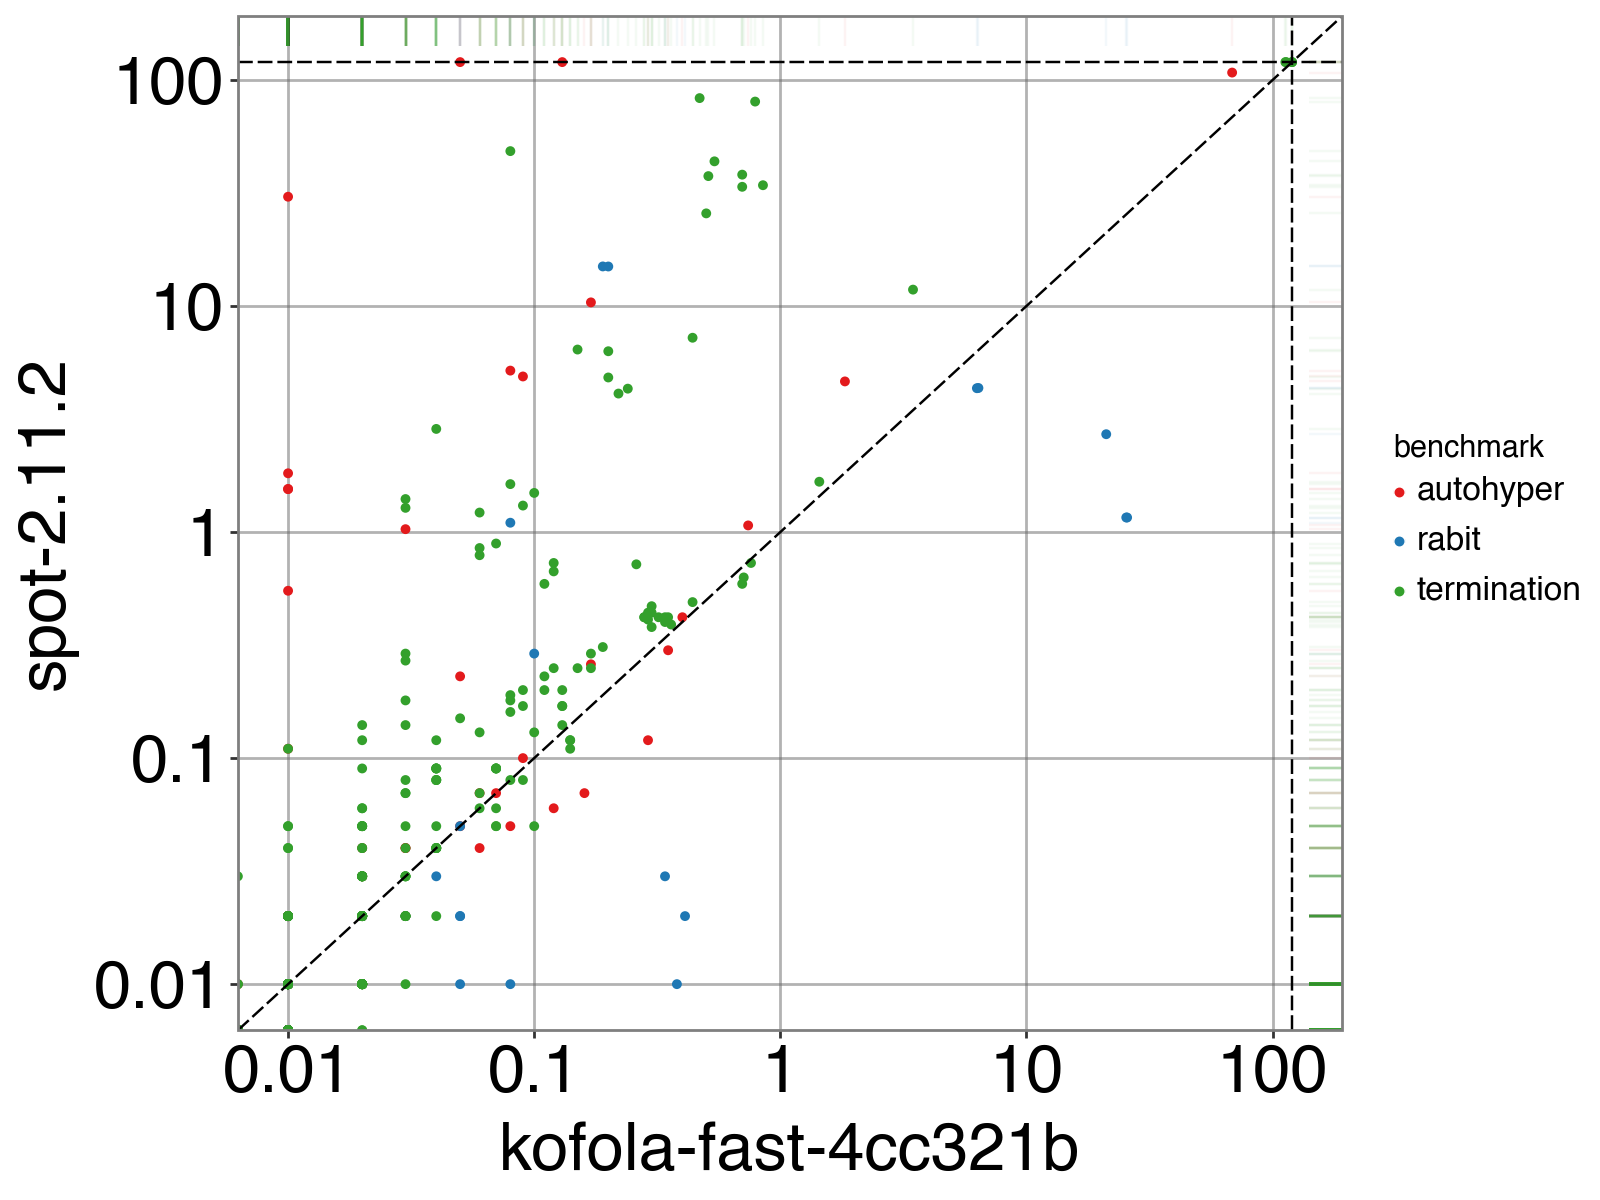

In [16]:
for tool in TOOLS:
    if tool != TOOL_FOR_COMPARISON:
        display(scatter_plot(df_all, TOOL_FOR_COMPARISON, tool, color_column="benchmark", timeout=TIMEOUT, legend_name_map={"advanced_automata_termination":"termination"}))

### More detailed evaluation

In [21]:
sanity_check(df_all, TOOL_FOR_COMPARISON, [tool for tool in TOOLS if tool!=TOOL_FOR_COMPARISON])

Loading ITables v2.4.4 from the internet... (need help?)


In [18]:
get_errors_incl(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)


In [19]:
get_solved_incl(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)


In [20]:
get_timeouts_incl(df_all, TOOL_FOR_COMPARISON)

Loading ITables v2.4.4 from the internet... (need help?)
